# Validação Estatística e Modelagem de Hipóteses (Regressão OLS)

O diagnóstico descritivo (EDA) da Cidade 11 apontou que longas distâncias (KM), o período noturno (Turno) e a falta de repasses financeiros (Eventos) degradam a performance da operação. O objetivo desta etapa é aplicar rigor estatístico para comprovar e quantificar essas hipóteses.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path

sns.set_theme(style="whitegrid")

In [3]:
processed_path = Path("../data/processed/05_BASE_TRATADA_PYTHON.csv")
df = pd.read_csv(processed_path)
df['data'] = pd.to_datetime(df['data'])
df['mes'] = df['data'].dt.strftime('%Y-%m')

df_escopo = df[(df['cidade_id'] == 11) & (df['mes'].isin(['2025-10', '2026-01']))].copy()

df_escopo['atraso_min'] = df_escopo['tempo_total_min'] - df_escopo['sla_min']

print(f"Base de Modelagem carregada com {len(df_escopo)} registros.")

Base de Modelagem carregada com 13315 registros.


### HIPOTESE 1: DISTÂNCIA INFLUENCIA PROPORCIONALMENTE NO ATRASO

TOTAL (Pearson): 0.3862
R² (Explicabilidade): 0.1491


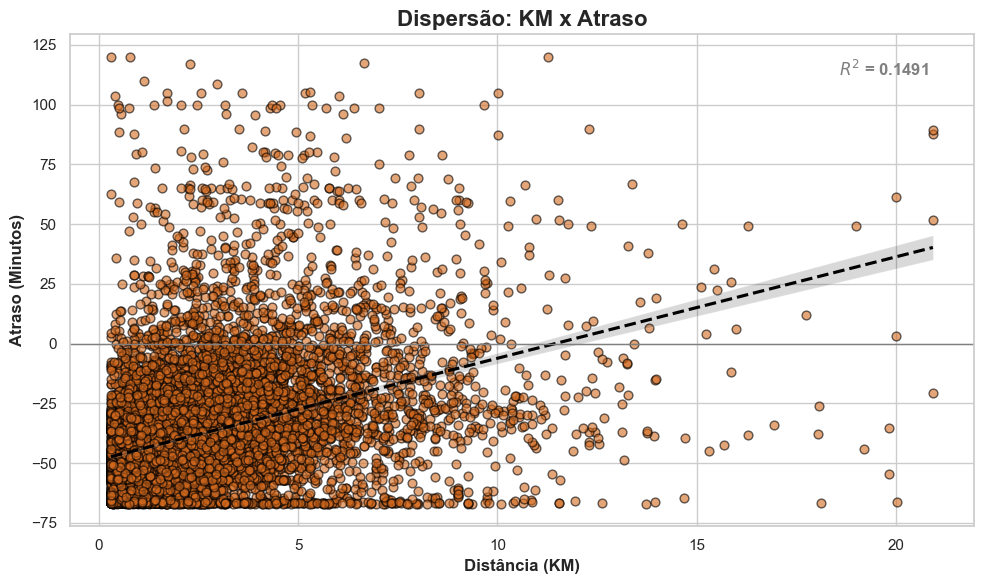

In [5]:
# 1. Cálculo da Correlação e do R²
correlacao_total = df_escopo['km'].corr(df_escopo['atraso_min'])
r_quadrado = correlacao_total ** 2

print(f"TOTAL (Pearson): {correlacao_total:.4f}")
print(f"R² (Explicabilidade): {r_quadrado:.4f}")

# 2. Gráfico de Dispersão com Linha de Tendência e R²
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_escopo, 
    x='km', 
    y='atraso_min', 
    scatter_kws={'alpha':0.6, 'color':'#D2691E', 'edgecolor':'black', 's':40}, 
    line_kws={'color':'black', 'linestyle':'--'}
)

# Adicionando o texto do R² no gráfico 
# Os valores x=0.95 e y=0.95 representam 95% do eixo 
plt.gca().text(0.95, 0.95, f'$R^2$ = {r_quadrado:.4f}', 
               transform=plt.gca().transAxes, 
               fontsize=12, fontweight='bold', color='gray',
               horizontalalignment='right', verticalalignment='top')

plt.title('Dispersão: KM x Atraso', fontsize=16, fontweight='bold')
plt.xlabel('Distância (KM)', fontsize=12, fontweight='bold')
plt.ylabel('Atraso (Minutos)', fontsize=12, fontweight='bold')
plt.axhline(0, color='gray', linestyle='-', linewidth=1) 

plt.tight_layout()
plt.show()

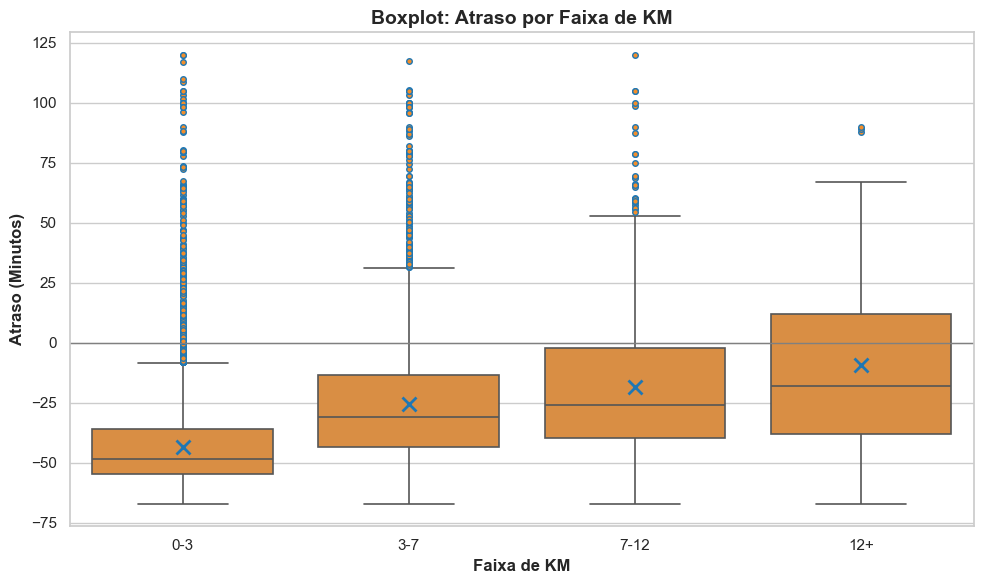

In [6]:
# --- BOXPLOT (DISTRIBUIÇÃO DO ATRASO) ---

# 1. Recriando a Faixa de KM
bins = [-np.inf, 3, 7, 12, np.inf]
labels = ['0-3', '3-7', '7-12', '12+']
df_escopo['faixa_km'] = pd.cut(df_escopo['km'], bins=bins, labels=labels)

# 2. Configurando a figura
plt.figure(figsize=(10, 6))

# 3. Gerando o Boxplot 
sns.boxplot(
    data=df_escopo,
    x='faixa_km',
    y='atraso_min',
    color='#F28E2B', 
    showmeans=True,  
    meanprops={"marker": "x", "markeredgecolor": "#1F77B4", "markersize": 10, "markeredgewidth": 2}, # O 'X' azul
    flierprops={"marker": "o", "markerfacecolor": "#F28E2B", "markeredgecolor": "#1F77B4", "markersize": 4}, # Bolinhas de outlier
    linewidth=1.2
)

# 4. Ajustes estéticos
plt.title('Boxplot: Atraso por Faixa de KM', fontsize=14, fontweight='bold')
plt.xlabel('Faixa de KM', fontsize=12, fontweight='bold')
plt.ylabel('Atraso (Minutos)', fontsize=12, fontweight='bold')
plt.axhline(0, color='gray', linestyle='-', linewidth=1) # Linha do SLA zero (onde o atraso começa)

plt.tight_layout()
plt.show()

#### Conclusão da H1: Distância × Atraso
A análise confirma que existe uma **relação positiva e estatisticamente significativa** 
entre a distância (KM) e o atraso nas entregas da Cidade 11.
**Principais achados:**
- A correlação de Pearson de **0.39** comprova a tendência: quanto maior a rota, 
  maior o atraso.
- Entretanto, o R² de **~15%** indica que a distância sozinha explica apenas uma 
  fração da variabilidade do atraso.
- A análise por faixas de KM reforça que o impacto se **intensifica drasticamente** 
  nas rotas acima de 7 km, com destaque para a faixa 12+ km.
**A H1 é validada como fator contribuinte, porém não como causa raiz isolada.** 
Os ~85% restantes da variação devem ser investigados nas hipóteses seguintes.